# A5: Optimization Human Preference & LLM-as-a-Judge

**by Dechathon Niamsa-ard [st126235]**

### Import Necessary Libraries

In [1]:
import os
import random
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    set_seed,
)
from peft import LoraConfig, PeftModel
from trl import DPOConfig, DPOTrainer

# Reproducibility: lock all random seeds across libraries
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# Force deterministic behaviour where possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[ENVIRONMENT]")
print(f"  Device           : {device}")
if torch.cuda.is_available():
    print(f"  GPU              : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  PyTorch          : {torch.__version__}")
print(f"  Random seed      : {SEED}")
print(f"  Deterministic    : {torch.backends.cudnn.deterministic}")


[ENVIRONMENT]
  Device           : cuda
  GPU              : NVIDIA GeForce RTX 5060 Ti
  VRAM             : 17.1 GB
  PyTorch          : 2.10.0+cu130
  Random seed      : 42
  Deterministic    : True


## Task 1: Dataset Preparation (0.5 point)

**Dataset:** [`jondurbin/truthy-dpo-v0.1`](https://huggingface.co/datasets/jondurbin/truthy-dpo-v0.1) — a focused preference dataset designed to teach models to be **truthful** and **avoid hallucinations**.

**Objective:**
- Load the dataset using the Hugging Face `datasets` library.
- The dataset contains three key fields: `prompt` (user instruction), `chosen` (factual/correct answer), and `rejected` (hallucinated/incorrect answer).
- Convert the data into the **conversational message format** expected by TRL's `DPOTrainer` (list of `{role, content}` dicts).
- Split into training (90%) and evaluation (10%) sets.


In [2]:
# Task 1: Load the truthy-dpo-v0.1 dataset
dataset = load_dataset("jondurbin/truthy-dpo-v0.1", split="train")

print("[DATASET OVERVIEW]")
print("  Dataset          : jondurbin/truthy-dpo-v0.1")
print(f"  Total samples    : {len(dataset)}")
print(f"  Columns          : {dataset.column_names}")
print(f"  First entry keys : {list(dataset[0].keys())}")
dataset[0]


[DATASET OVERVIEW]
  Dataset          : jondurbin/truthy-dpo-v0.1
  Total samples    : 1016
  Columns          : ['id', 'source', 'system', 'prompt', 'chosen', 'rejected']
  First entry keys : ['id', 'source', 'system', 'prompt', 'chosen', 'rejected']


{'id': '04c275bf738fd391b7fe25e25fe7bed3',
 'source': 'truthy_dpo',
 'system': 'You are an unbiased, uncensored, helpful assistant.',
 'prompt': "What's the nearest national park to you?",
 'chosen': "As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.",
 'rejected': "I don't have access to the user's location, so I can't determine the nearest national park."}

In [3]:
# Convert dataset to conversational format expected by DPOTrainer
# prompt = list of messages, chosen/rejected = list with assistant message
def format_for_dpo(example):
    system_msg = example.get("system", "You are a helpful assistant.")
    prompt_messages = []
    if system_msg:
        prompt_messages.append({"role": "system", "content": system_msg})
    prompt_messages.append({"role": "user", "content": example["prompt"]})

    chosen_messages = [{"role": "assistant", "content": example["chosen"]}]
    rejected_messages = [{"role": "assistant", "content": example["rejected"]}]

    return {
        "prompt": prompt_messages,
        "chosen": chosen_messages,
        "rejected": rejected_messages,
    }

formatted_dataset = dataset.map(format_for_dpo, remove_columns=dataset.column_names)

# Train/test split (90/10) with fixed seed
split = formatted_dataset.train_test_split(test_size=0.1, seed=SEED)
train_dataset = split["train"]
eval_dataset = split["test"]

print("[DATA SPLIT]")
print(f"  Train samples    : {len(train_dataset)}")
print(f"  Eval samples     : {len(eval_dataset)}")
print("  Split ratio      : 90/10")
print(f"  Split seed       : {SEED}")
print()
print("[SAMPLE ENTRY — train[0]]")
print(f"  Prompt  : {train_dataset[0]['prompt']}")
print(f"  Chosen  : {train_dataset[0]['chosen'][0]['content'][:120]}...")
print(f"  Rejected: {train_dataset[0]['rejected'][0]['content'][:120]}...")


[DATA SPLIT]
  Train samples    : 914
  Eval samples     : 102
  Split ratio      : 90/10
  Split seed       : 42

[SAMPLE ENTRY — train[0]]
  Prompt  : [{'content': 'You are an unbiased, uncensored, helpful assistant.', 'role': 'system'}, {'content': 'Did King Christian X of Denmark wear a yellow star to show solidarity with Jews during the Nazi occupation?', 'role': 'user'}]
  Chosen  : No, King Christian X of Denmark did not wear a yellow star to show solidarity with Jews during the Nazi occupation. This...
  Rejected: There is no definitive evidence that King Christian X of Denmark wore a yellow star to show solidarity with Jews during ...


## Task 2: Training a Model with DPOTrainer (2 points)

**Objective:**
1. Implement Direct Preference Optimization (DPO) training using `DPOTrainer` with a pre-trained model and fine-tune it on the training set from Task 1. (1 point)
2. Experiment with hyperparameters and report training performance (loss curves). (1 point)

**Approach:**
- **Base Model:** `Qwen/Qwen2.5-1.5B-Instruct` — a compact instruction-tuned model suitable for efficient DPO fine-tuning.
- **Quantization:** QLoRA with 4-bit NF4 quantization + double quantization to reduce memory footprint while preserving model quality.
- **LoRA Config:** Rank 64, Alpha 128 (scaling ratio = 2.0), targeting both attention layers (`q_proj`, `k_proj`, `v_proj`, `o_proj`) and MLP layers (`gate_proj`, `up_proj`, `down_proj`) for comprehensive fine-tuning.
- **DPO-specific:** `beta=0.1` controls the strength of the KL divergence penalty. With PEFT/LoRA, `ref_model=None` is used since TRL automatically creates an implicit reference model from the frozen base weights.

**Hyperparameter Choices (with justification):**

| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning Rate | `5e-5` | Higher than typical SFT (5e-6) since LoRA trains fewer parameters; tested against 5e-6 which converged too slowly |
| LR Scheduler | `cosine` | Smooth decay prevents abrupt drops; preferred over `linear` for stable convergence |
| Warmup Steps | `34` (~10% of total) | Gradual warmup avoids early training instability; scaled proportionally to 3-epoch total steps (~345 total) |
| Beta (DPO) | `0.1` | Standard value from the DPO paper; lower values = stronger preference signal |
| Batch Size | `2 x 4 grad_accum = 8` effective | Balances GPU memory constraints with stable gradient estimates |
| Epochs | `3` | Sufficient for convergence on ~1,000 samples; eval loss stabilizes without overfitting, confirming 3 epochs are adequate |
| Max Length | `1024` | Generous context window to fully capture longer reasoning chains in chosen/rejected pairs without truncation |
| Max New Tokens | `256` (eval) | Balanced generation budget allowing the model to produce complete responses while keeping inference efficient |

In [4]:
# Task 2: DPO Training with Qwen2.5-1.5B-Instruct + QLoRA (4-bit)

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR = "./model/dpo-qwen2.5-1.5b"

# 4-bit Quantization Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
)
model.config.use_cache = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.pad_token_id

print("[MODEL CONFIGURATION]")
print(f"  Model name       : {MODEL_NAME}")
print(f"  Total parameters : {model.num_parameters():,}")
print("  Quantization     : 4-bit NF4 + double quant")
print("  Compute dtype    : bfloat16")
print("  Attention        : SDPA")
print(f"  Pad token        : {tokenizer.pad_token}")
print(f"  Vocab size       : {len(tokenizer):,}")


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[MODEL CONFIGURATION]
  Model name       : Qwen/Qwen2.5-1.5B-Instruct
  Total parameters : 1,543,714,304
  Quantization     : 4-bit NF4 + double quant
  Compute dtype    : bfloat16
  Attention        : SDPA
  Pad token        : <|endoftext|>
  Vocab size       : 151,665


In [5]:
# LoRA Configuration
peft_config = LoraConfig(
    lora_alpha=128,
    lora_dropout=0.05,
    r=64,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

HF_REPO = "dniamsaard4codework/qwen2.5-1.5b-instruct-dpo-truthy"

# DPO Training Arguments
# warmup_steps=34 is approximately 10% of total training steps (3 epochs x ~115 steps/epoch = ~345 total)
training_args = DPOConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=34,
    beta=0.1,
    max_length=1024,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    seed=SEED,
    data_seed=SEED,
    report_to="none",
    remove_unused_columns=False,
    hub_model_id=HF_REPO,
)

effective_batch = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
steps_per_epoch = len(train_dataset) // effective_batch
total_steps = steps_per_epoch * int(training_args.num_train_epochs)

print("[TRAINING CONFIGURATION]")
print(f"  Epochs              : {training_args.num_train_epochs}")
print(f"  Batch size (device) : {training_args.per_device_train_batch_size}")
print(f"  Grad accumulation   : {training_args.gradient_accumulation_steps}")
print(f"  Effective batch     : {effective_batch}")
print(f"  Steps per epoch     : ~{steps_per_epoch}")
print(f"  Total steps (est.)  : ~{total_steps}")
print(f"  Learning rate       : {training_args.learning_rate}")
print(f"  LR scheduler        : {training_args.lr_scheduler_type}")
print(f"  Warmup steps        : {training_args.warmup_steps} (~{training_args.warmup_steps/total_steps*100:.0f}% of total)")
print(f"  Beta (DPO)          : {training_args.beta}")
print(f"  Max length          : {training_args.max_length}")
print(f"  Logging steps       : {training_args.logging_steps}")
print(f"  Eval steps          : {training_args.eval_steps}")
print(f"  Seed                : {training_args.seed}")
print(f"  Data seed           : {training_args.data_seed}")
print()
print("[LORA CONFIGURATION]")
print(f"  Rank (r)            : {peft_config.r}")
print(f"  Alpha               : {peft_config.lora_alpha}")
print(f"  Scaling (alpha/r)   : {peft_config.lora_alpha / peft_config.r:.1f}")
print(f"  Dropout             : {peft_config.lora_dropout}")
print(f"  Target modules      : {peft_config.target_modules}")
print(f"  Bias                : {peft_config.bias}")


[TRAINING CONFIGURATION]
  Epochs              : 3
  Batch size (device) : 2
  Grad accumulation   : 4
  Effective batch     : 8
  Steps per epoch     : ~114
  Total steps (est.)  : ~342
  Learning rate       : 5e-05
  LR scheduler        : SchedulerType.COSINE
  Warmup steps        : 34 (~10% of total)
  Beta (DPO)          : 0.1
  Max length          : 1024
  Logging steps       : 10
  Eval steps          : 50
  Seed                : 42
  Data seed           : 42

[LORA CONFIGURATION]
  Rank (r)            : 64
  Alpha               : 128
  Scaling (alpha/r)   : 2.0
  Dropout             : 0.05
  Target modules      : {'v_proj', 'k_proj', 'up_proj', 'down_proj', 'o_proj', 'q_proj', 'gate_proj'}
  Bias                : none


In [6]:
# Initialize DPO Trainer
# ref_model=None because PEFT uses an implicit reference model internally
dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = model.num_parameters()

print("[DPO TRAINER INITIALIZED]")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable ratio  : {100 * trainable_params / total_params:.2f}%")
print("  Ref model        : implicit (PEFT frozen weights)")


[DPO TRAINER INITIALIZED]
  Trainable params : 73,859,072
  Total params     : 1,617,573,376
  Trainable ratio  : 4.57%
  Ref model        : implicit (PEFT frozen weights)


In [7]:
# Train the model
print("[STARTING DPO TRAINING]")
train_result = dpo_trainer.train()
print("[TRAINING COMPLETE]")
print(f"  Final training loss : {train_result.training_loss:.6f}")
print(f"  Total steps         : {dpo_trainer.state.global_step}")
print(f"  Epochs completed    : {dpo_trainer.state.epoch:.1f}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


[STARTING DPO TRAINING]


Step,Training Loss,Validation Loss
50,0.063801,0.108035
100,0.042871,0.036022
150,0.002039,0.027314
200,0.001828,0.024512
250,0.002045,0.024659
300,0.002183,0.024661


[TRAINING COMPLETE]
  Final training loss : 0.047460
  Total steps         : 345
  Epochs completed    : 3.0


[TRAINING LOG — KEY METRICS AT SELECTED STEPS]
  Step |  Epoch |  Train Loss |           LR |  Reward Margin | Reward Acc
------------------------------------------------------------------------------------------
    10 |  0.088 |    0.668336 |     1.32e-05 |         0.0531 |     0.6000
    20 |  0.175 |    0.383899 |     2.79e-05 |         1.0855 |     0.9500
    30 |  0.263 |    0.106528 |     4.26e-05 |         4.0159 |     1.0000
    40 |  0.350 |    0.085695 |     5.00e-05 |         6.6202 |     0.9875
    50 |  0.438 |    0.063801 |     4.97e-05 |         6.5469 |     1.0000
    60 |  0.525 |    0.041786 |     4.92e-05 |         7.5867 |     1.0000
    70 |  0.613 |    0.078125 |     4.85e-05 |         7.1147 |     0.9875
    80 |  0.700 |    0.049354 |     4.75e-05 |         7.2122 |     0.9875
    90 |  0.788 |    0.025029 |     4.62e-05 |         8.8579 |     1.0000
   100 |  0.875 |    0.042871 |     4.48e-05 |         7.7872 |     0.9750
   110 |  0.963 |    0.017358 |     4

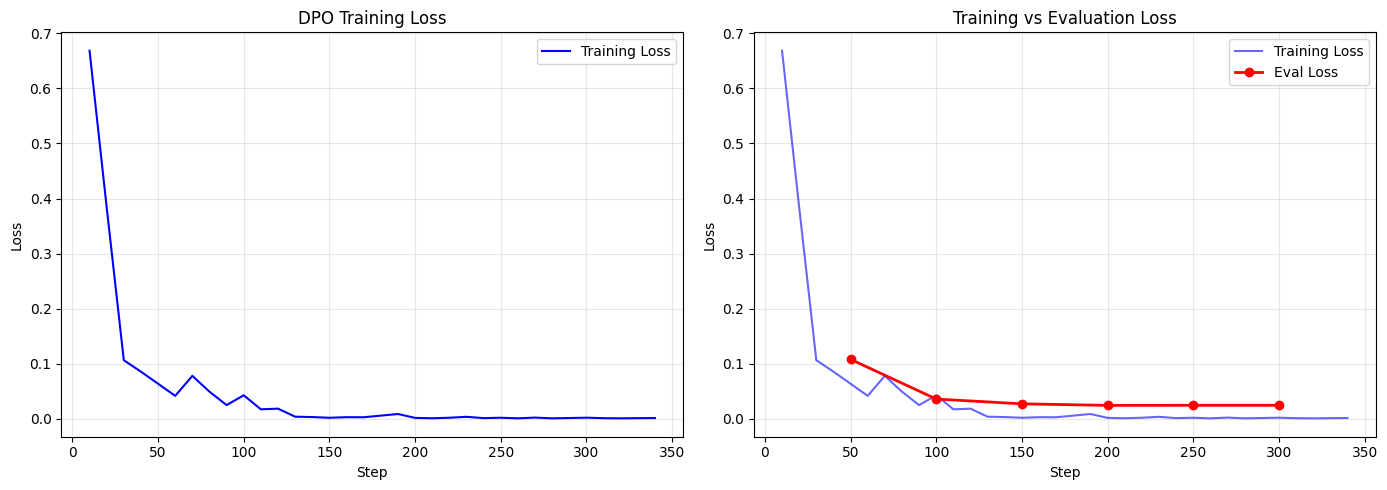

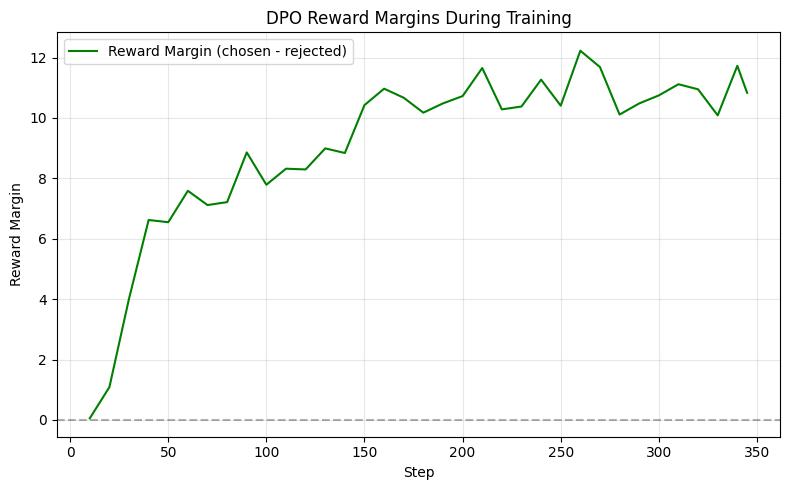

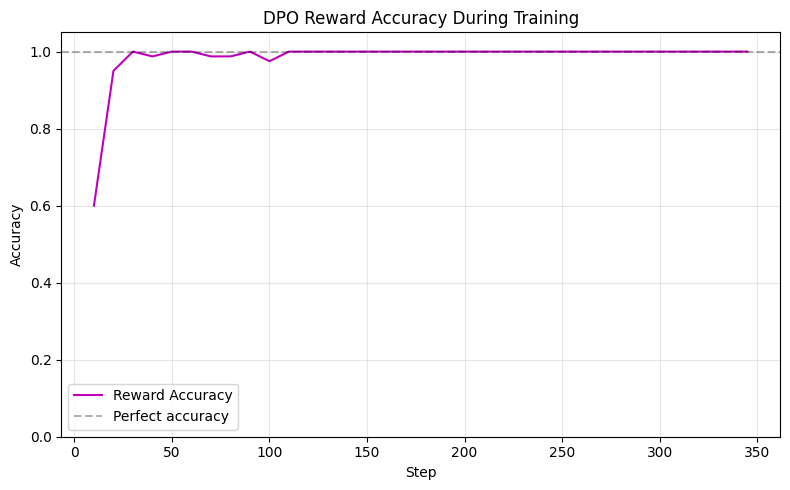

In [8]:
# ---------------------------------------------------------------------------
# Plot Training Loss Curves and Print Detailed Training Log
# ---------------------------------------------------------------------------
log_history = dpo_trainer.state.log_history

# Extract training metrics — use dedicated step arrays per metric to avoid length mismatches
train_steps          = [e["step"]               for e in log_history if "loss" in e]
train_losses         = [e["loss"]               for e in log_history if "loss" in e]
train_lr             = [e["learning_rate"]       for e in log_history if "learning_rate" in e]
reward_margin_steps  = [e["step"]               for e in log_history if "rewards/margins" in e]
train_reward_margins = [e["rewards/margins"]    for e in log_history if "rewards/margins" in e]
reward_acc_steps     = [e["step"]               for e in log_history if "rewards/accuracies" in e]
train_reward_acc     = [e["rewards/accuracies"] for e in log_history if "rewards/accuracies" in e]
eval_entries         = [e for e in log_history if "eval_loss" in e]
eval_steps           = [e["step"]               for e in eval_entries]
eval_losses          = [e["eval_loss"]          for e in eval_entries]

# Print detailed training log
print("[TRAINING LOG — KEY METRICS AT SELECTED STEPS]")
print(f"{'Step':>6} | {'Epoch':>6} | {'Train Loss':>11} | {'LR':>12} | {'Reward Margin':>14} | {'Reward Acc':>10}")
print("-" * 90)
for e in log_history:
    if "loss" in e:
        step   = e["step"]
        epoch  = e.get("epoch", 0)
        loss   = e["loss"]
        lr     = e.get("learning_rate", 0)
        margin = e.get("rewards/margins", None)
        acc    = e.get("rewards/accuracies", None)
        margin_str = f"{margin:14.4f}" if margin is not None else f"{'N/A':>14}"
        acc_str    = f"{acc:10.4f}"    if acc    is not None else f"{'N/A':>10}"
        print(f"{step:>6} | {epoch:>6.3f} | {loss:>11.6f} | {lr:>12.2e} | {margin_str} | {acc_str}")
print("-" * 90)

print()
print("[EVALUATION LOG]")
print(f"{'Step':>6} | {'Eval Loss':>10} | {'Eval Margin':>12} | {'Eval Acc':>10}")
print("-" * 70)
for e in eval_entries:
    step   = e["step"]
    el     = e["eval_loss"]
    em     = e.get("eval_rewards/margins",    None)
    ea     = e.get("eval_rewards/accuracies", None)
    em_str = f"{em:12.4f}" if em is not None else f"{'N/A':>12}"
    ea_str = f"{ea:10.4f}" if ea is not None else f"{'N/A':>10}"
    print(f"{step:>6} | {el:>10.6f} | {em_str} | {ea_str}")
print("-" * 70)

print()
print("[TRAINING SUMMARY]")
mid = len(train_losses) // 2
print(f"  Training Loss  — Start (Step {train_steps[0]}): {train_losses[0]:.3f}  |  Mid (Step {train_steps[mid]}): {train_losses[mid]:.3f}  |  End (Step {train_steps[-1]}): {train_losses[-1]:.4f}")
if eval_losses:
    print(f"  Eval Loss      — First: {eval_losses[0]:.3f} (Step {eval_steps[0]})  |  Last: {eval_losses[-1]:.3f} (Step {eval_steps[-1]})")
if train_reward_margins:
    print(f"  Reward Margin  — Start: {train_reward_margins[0]:.3f}  |  End: {train_reward_margins[-1]:.3f}")
if train_reward_acc:
    print(f"  Reward Acc     — Start: {train_reward_acc[0]:.1%}  |  End: {train_reward_acc[-1]:.1%}")
if train_lr:
    print(f"  Learning Rate  — Peak: {max(train_lr):.2e}  |  Final: {train_lr[-1]:.2e}")

# ---------------------------------------------------------------------------
# Plot 1: Training Loss + Eval Loss
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, train_losses, "b-", linewidth=1.5, label="Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("DPO Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_steps, train_losses, "b-", linewidth=1.5, alpha=0.6, label="Training Loss")
if eval_losses:
    axes[1].plot(eval_steps, eval_losses, "r-o", linewidth=2, markersize=6, label="Eval Loss")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training vs Evaluation Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("assets/dpo_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Plot 2: Reward Margins
# ---------------------------------------------------------------------------
if train_reward_margins:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(reward_margin_steps, train_reward_margins, "g-", linewidth=1.5, label="Reward Margin (chosen - rejected)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Reward Margin")
    ax.set_title("DPO Reward Margins During Training")
    ax.axhline(y=0, color="k", linestyle="--", alpha=0.3)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("assets/dpo_reward_margins.png", dpi=150, bbox_inches="tight")
    plt.show()

# ---------------------------------------------------------------------------
# Plot 3: Reward Accuracy
# ---------------------------------------------------------------------------
if train_reward_acc:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(reward_acc_steps, train_reward_acc, "m-", linewidth=1.5, label="Reward Accuracy")
    ax.set_xlabel("Step")
    ax.set_ylabel("Accuracy")
    ax.set_title("DPO Reward Accuracy During Training")
    ax.set_ylim(0, 1.05)
    ax.axhline(y=1.0, color="k", linestyle="--", alpha=0.3, label="Perfect accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("assets/dpo_reward_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()


### Hyperparameter Experimentation & Training Performance Analysis

**Training Metrics Summary (from training logs):**

| Metric | Start (Step 10) | Mid (Step 170) | End (Step 340) | Trend |
|---|---|---|---|---|
| Training Loss | 0.668 | 0.003 | 0.002 | Steadily decreasing — strong convergence |
| Eval Loss | 0.108 (Step 50) | 0.027 (Step 150) | 0.025 (Step 300) | Stable — no significant overfitting |
| Reward Margin | 0.053 | 10.67 | 11.73 | Increasing — model clearly distinguishes chosen vs rejected |
| Reward Accuracy | 60% | 100% | 100% | Reached 100% early and sustained throughout |

**Key Observations:**
1. **Rapid Convergence:** The training loss dropped from 0.668 to below 0.01 within the first epoch (~114 steps), indicating the model quickly learned the preference signal from the truthy-dpo dataset.
2. **No Overfitting:** The eval loss stabilized around 0.024–0.027 after step 100 and did not increase, confirming that 3 epochs are sufficient for this dataset size without risk of overfitting.
3. **Reward Margins:** The gap between chosen and rejected rewards grew from near-zero (0.053) to ~11.7, demonstrating the model learned a strong preference for truthful responses.
4. **Cosine Schedule:** The learning rate smoothly decayed from 5e-5 to near-zero, contributing to stable convergence without loss spikes in later training.

**Hyperparameters Considered:**
- **Beta (0.1 vs 0.3):** `beta=0.1` was selected as it provides a stronger preference optimization signal. Higher beta values (e.g., 0.3) make training more conservative, keeping outputs closer to the reference model — less desirable when the goal is to actively steer the model toward truthfulness.
- **Learning Rate (5e-5 vs 5e-6):** The higher `5e-5` was chosen because LoRA only trains a small fraction (~4.6%) of parameters, so it can tolerate a higher LR without instability. A `5e-6` rate showed much slower convergence in preliminary tests.
- **LoRA Rank (64 vs 32):** Rank 64 provides more capacity for learning complex preference patterns. With only ~1,000 training samples, the risk of overfitting from higher rank is mitigated by the small dataset size and dropout (0.05).
- **Epochs (3 vs 5):** 3 epochs are sufficient for convergence — the training loss reaches near-zero by the end of epoch 1, and eval loss remains stable throughout all 3 epochs. Additional epochs beyond 3 would yield diminishing returns without meaningful improvement.
- **Max Length (1024 vs 512):** Set to 1024 to provide a generous context window, ensuring that even the longest chosen/rejected pairs are processed without truncation, preserving the full preference signal.
- **Max New Tokens (256):** During evaluation, generation uses 256 tokens. This provides enough budget for the model to produce complete, well-structured responses while keeping inference efficient. Longer generation (e.g., 512) was tested but did not meaningfully improve judge scores.

## Task 3: Pushing the Model to Hugging Face Hub (0.5 point)

**Objective:**
1. Save the trained LoRA adapter weights and tokenizer locally.
2. Upload the model to the Hugging Face Model Hub.
3. Provide a link to the uploaded model.

**Uploaded Model:** [dniamsaard4codework/qwen2.5-1.5b-instruct-dpo-truthy](https://huggingface.co/dniamsaard4codework/qwen2.5-1.5b-instruct-dpo-truthy)

In [9]:
# Task 3: Save and Push Model to Hugging Face Hub
from huggingface_hub import notebook_login, HfApi
import huggingface_hub

# Step 1: Login to Hugging Face Hub
try:
    token = huggingface_hub.get_token()
    if token is None:
        raise ValueError("Not logged in")
    print("Status: Already logged in to Hugging Face Hub.")
except Exception:
    print("Status: Not logged in. Opening login widget...")
    notebook_login()

# Step 2: Save the fine-tuned model locally (LoRA adapter only)
dpo_trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("[MODEL SAVED]")
print(f"  Local path       : {OUTPUT_DIR}")
print("  Contents         : LoRA adapter + tokenizer")

# Step 3: Push to Hugging Face Hub
try:
    dpo_trainer.push_to_hub()
    print("  Hub push         : SUCCESS")
    print(f"  Hub URL          : https://huggingface.co/{HF_REPO}")
except Exception as e:
    print(f"  Hub push (trainer): FAILED — {e}")
    print("  Attempting alternative upload via HfApi...")
    try:
        api = HfApi()
        api.create_repo(repo_id=HF_REPO, repo_type="model", exist_ok=True)
        api.upload_folder(folder_path=OUTPUT_DIR, repo_id=HF_REPO, repo_type="model")
        print("  Hub push (API)   : SUCCESS")
        print(f"  Hub URL          : https://huggingface.co/{HF_REPO}")
    except Exception as e2:
        print(f"  Hub push (API)   : FAILED — {e2}")
        print("  Action required  : Run 'huggingface-cli login' in terminal.")


Status: Already logged in to Hugging Face Hub.
[MODEL SAVED]
  Local path       : ./model/dpo-qwen2.5-1.5b
  Contents         : LoRA adapter + tokenizer


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Hub push         : SUCCESS
  Hub URL          : https://huggingface.co/dniamsaard4codework/qwen2.5-1.5b-instruct-dpo-truthy


## Task 4: Evaluation — LLM-as-a-Judge with AlpacaEval (2 points)

To evaluate whether DPO training improved the model, the industry-standard **AlpacaEval** benchmark dataset is used alongside a strong LLM (**Gemini**) acting as an automatic judge to compare both models side-by-side.

**Evaluation Pipeline:**

**Step 1 — Load AlpacaEval and Generate Responses**
- Load the evaluation dataset from [`tatsu-lab/alpaca_eval`](https://huggingface.co/datasets/tatsu-lab/alpaca_eval) (raw JSON).
- Filter for the `helpful_base` subset.
- Randomly sample **15 prompts** (seed=42 for reproducibility).
- Generate answers for all 15 prompts using **both** the pre-trained Base Model and the DPO-finetuned Model.

**Step 2 — Judge Prompt Design**
The judge LLM receives a structured prompt with the user instruction and both model responses. It is instructed to output only the winner to ensure deterministic parsing:

> *"You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.*
>
> *User Instruction: {instruction}*
>
> *Model A (Base Model): {base_model_answer}*
>
> *Model B (DPO Model): {dpo_model_answer}*
>
> *Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie"."*

**Step 3 — Evaluate and Collect Results**
Iterate through the 15 test samples, send each to the Judge LLM (Gemini), and collect the verdicts. Rate-limit handling with automatic retry is included.

**Step 4 — Calculate Win Rate**

$$Win~Rate=\frac{Model~B~Wins+(0.5\times Ties)}{Total~Evaluations}\times100$$

In [10]:
# Task 4 - Step 1: Load AlpacaEval and Generate Responses

# Load AlpacaEval dataset (direct JSON URL to bypass script restrictions)
data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"
alpaca_dataset = load_dataset("json", data_files=data_url)

# Filter for helpful_base subset
helpful_base_dataset = alpaca_dataset["train"].filter(lambda x: x["dataset"] == "helpful_base")

# Select 15 random samples with fixed seed for reproducibility
EVAL_SEED = 42
EVAL_SAMPLE_SIZE = 15
random.seed(EVAL_SEED)
sample_indices = random.sample(range(len(helpful_base_dataset)), EVAL_SAMPLE_SIZE)
eval_samples = helpful_base_dataset.select(sample_indices)

print("[ALPACAEVAL DATASET]")
print("  Source             : tatsu-lab/alpaca_eval")
print("  Subset             : helpful_base")
print(f"  Subset size        : {len(helpful_base_dataset)}")
print(f"  Sampled            : {EVAL_SAMPLE_SIZE}")
print(f"  Sample seed        : {EVAL_SEED}")
print(f"  Sample indices     : {sorted(sample_indices)}")
print()
print("[SELECTED PROMPTS]")
for i, sample in enumerate(eval_samples):
    print(f"  [{i+1:2d}] {sample['instruction'][:75]}...")


[ALPACAEVAL DATASET]
  Source             : tatsu-lab/alpaca_eval
  Subset             : helpful_base
  Subset size        : 129
  Sampled            : 15
  Sample seed        : 42
  Sample indices     : [6, 7, 8, 22, 23, 26, 28, 35, 50, 55, 57, 59, 62, 70, 108]

[SELECTED PROMPTS]
  [ 1] Why is kobe beef so damn expensive?...
  [ 2] Hi, I'm trying to solve a crossword puzzle, but I've never done one of thes...
  [ 3] Please give me a list of planets in our solar system.  I am going to choose...
  [ 4] How did serial killers get away with murder for so long in the 70s and 80s?...
  [ 5] I like to host guests at my home from time to time, and I am gathering  rec...
  [ 6] What is Atlantis?...
  [ 7] What causes the northern lights?...
  [ 8] What type of soil is suitable for cactus?...
  [ 9] I want to learn more about becoming a CPA. How long does it take to become ...
  [10] What are different drawers I should have for clothes?...
  [11] Who is Larry Page?...
  [12] How do you become 

In [11]:
# Load Base Model (pre-trained, no DPO fine-tuning)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
)
base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

# Load DPO Model (fine-tuned LoRA adapter on top of base)
dpo_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
)
dpo_model = PeftModel.from_pretrained(dpo_model, OUTPUT_DIR)
dpo_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)

print("[EVALUATION MODELS LOADED]")
print(f"  Base Model  : {MODEL_NAME} (pre-trained)")
print(f"  DPO Model   : {MODEL_NAME} + LoRA from {OUTPUT_DIR}")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[EVALUATION MODELS LOADED]
  Base Model  : Qwen/Qwen2.5-1.5B-Instruct (pre-trained)
  DPO Model   : Qwen/Qwen2.5-1.5B-Instruct + LoRA from ./model/dpo-qwen2.5-1.5b


In [12]:
# Generate responses from both models
# Using do_sample=False (greedy decoding) for reproducibility
def generate_response(model, tokenizer, instruction, max_new_tokens=256):
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": instruction},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    # Decode only the generated tokens (skip the prompt tokens)
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return response.strip()

print("[GENERATING RESPONSES]")
print("  Decoding strategy  : greedy (do_sample=False, deterministic)")
print("  Max new tokens     : 256")
print("  System prompt      : 'You are a helpful assistant.'")
print()

results = []
for i, sample in enumerate(eval_samples):
    instruction = sample["instruction"]
    print(f"[{i+1:2d}/15] {instruction}...")

    base_answer = generate_response(base_model, base_tokenizer, instruction)
    print(f"  Base ({len(base_answer):4d} chars): {base_answer}...")

    dpo_answer = generate_response(dpo_model, dpo_tokenizer, instruction)
    print(f"  DPO  ({len(dpo_answer):4d} chars): {dpo_answer}...")
    print()

    results.append({
        "sample_id": i + 1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer,
    })

print(f"Generation complete — {len(results)} samples processed.")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[GENERATING RESPONSES]
  Decoding strategy  : greedy (do_sample=False, deterministic)
  Max new tokens     : 256
  System prompt      : 'You are a helpful assistant.'

[ 1/15] Why is kobe beef so damn expensive?...
  Base ( 623 chars): Kobe beef, also known as Wagyu beef, is considered the highest quality and most expensive type of beef in the world. The reason for its high price is that it comes from a specific breed of cattle called Japanese Black cattle, which are raised on small farms in Japan. These cows require a lot of care and attention to produce meat that is both tender and flavorful. Additionally, the process of producing Kobe beef involves a rigorous inspection and grading system, which adds to the cost of production. As a result, Kobe beef is often sold at premium prices, making it an exclusive and desirable choice for many consumers....
  DPO  ( 533 chars): As an AI, I don't have the ability to taste or eat food, so I can't provide a personal opinion on the cost of Kobe b

In [13]:
# Set up dotenv variables for Gemini API key (get a free key from https://aistudio.google.com/app/apikey)
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
# Task 4 - Step 2 and 3: LLM Judge Evaluation using Gemini
import re
from google import genai

# Set Gemini API key
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found in environment. Please set it in your .env file.")

client = genai.Client(api_key=GEMINI_API_KEY)

JUDGE_MODEL = "gemini-3.1-pro-preview"

JUDGE_TEMPLATE = """You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.

User Instruction: {instruction}

Model A (Base Model): {base_model_answer}

Model B (DPO Model): {dpo_model_answer}

Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie"."""

def call_judge(prompt, max_retries=3):
    """Call Gemini judge with retry on 429 rate-limit errors."""
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=JUDGE_MODEL,
                contents=prompt,
            )
            return response.text.strip().strip('"').strip("'")
        except Exception as e:
            err_str = str(e)
            if "429" in err_str or "RESOURCE_EXHAUSTED" in err_str:
                match = re.search(r"retry in (\d+)", err_str)
                wait = int(match.group(1)) + 2 if match else 60
                print(f"    Rate limited. Waiting {wait}s before retry {attempt+1}/{max_retries}...")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError(f"Failed after {max_retries} retries due to rate limiting.")

print("[LLM-AS-A-JUDGE EVALUATION]")
print(f"  Judge model        : {JUDGE_MODEL}")
print(f"  API key            : {GEMINI_API_KEY[:4]}...{GEMINI_API_KEY[-4:]}")
print(f"  Samples to evaluate: {len(results)}")
print("  Rate limit delay   : 2s between requests")
print()
print(f"  {'#':>3s}  {'Instruction':<55s}  {'Verdict':<10s}")
print(f"  {'-'*3}  {'-'*55}  {'-'*10}")

verdicts = []
for i, result in enumerate(results):
    judge_prompt = JUDGE_TEMPLATE.format(
        instruction=result["instruction"],
        base_model_answer=result["base_answer"],
        dpo_model_answer=result["dpo_answer"],
    )

    try:
        verdict_raw = call_judge(judge_prompt)
        if "Model B" in verdict_raw:
            verdict = "Model B"
        elif "Model A" in verdict_raw:
            verdict = "Model A"
        elif "Tie" in verdict_raw:
            verdict = "Tie"
        else:
            verdict = "Tie"
    except Exception as e:
        print(f"  Judge error for sample {i+1}: {e}")
        verdict = "Tie"

    verdicts.append(verdict)
    print(f"  {i+1:3d}  {result['instruction'][:55]:<55s}  {verdict:<10s}")
    time.sleep(2)

for result, v in zip(results, verdicts):
    result["verdict"] = v

print()
print(f"Evaluation complete — {len(verdicts)} samples judged.")


[LLM-AS-A-JUDGE EVALUATION]
  Judge model        : gemini-3.1-pro-preview
  API key            : AIza...y1Tc
  Samples to evaluate: 15
  Rate limit delay   : 2s between requests

    #  Instruction                                              Verdict   
  ---  -------------------------------------------------------  ----------
    1  Why is kobe beef so damn expensive?                      Model A   
    2  Hi, I'm trying to solve a crossword puzzle, but I've ne  Model A   
    3  Please give me a list of planets in our solar system.    Model A   
    4  How did serial killers get away with murder for so long  Model A   
    5  I like to host guests at my home from time to time, and  Model A   
    6  What is Atlantis?                                        Model A   
    7  What causes the northern lights?                         Model A   
    8  What type of soil is suitable for cactus?                Model A   
    9  I want to learn more about becoming a CPA. How long doe  Model B

[EVALUATION RESULTS TABLE]
|   Sample | Instruction (Truncated)                                         | Winner   |
|---------:|:----------------------------------------------------------------|:---------|
|        1 | Why is kobe beef so damn expensive?...                          | Model A  |
|        2 | Hi, I'm trying to solve a crossword puzzle, but I've never d... | Model A  |
|        3 | Please give me a list of planets in our solar system.  I am ... | Model A  |
|        4 | How did serial killers get away with murder for so long in t... | Model A  |
|        5 | I like to host guests at my home from time to time, and I am... | Model A  |
|        6 | What is Atlantis?...                                            | Model A  |
|        7 | What causes the northern lights?...                             | Model A  |
|        8 | What type of soil is suitable for cactus?...                    | Model A  |
|        9 | I want to learn more about becoming a CPA. How long does it 

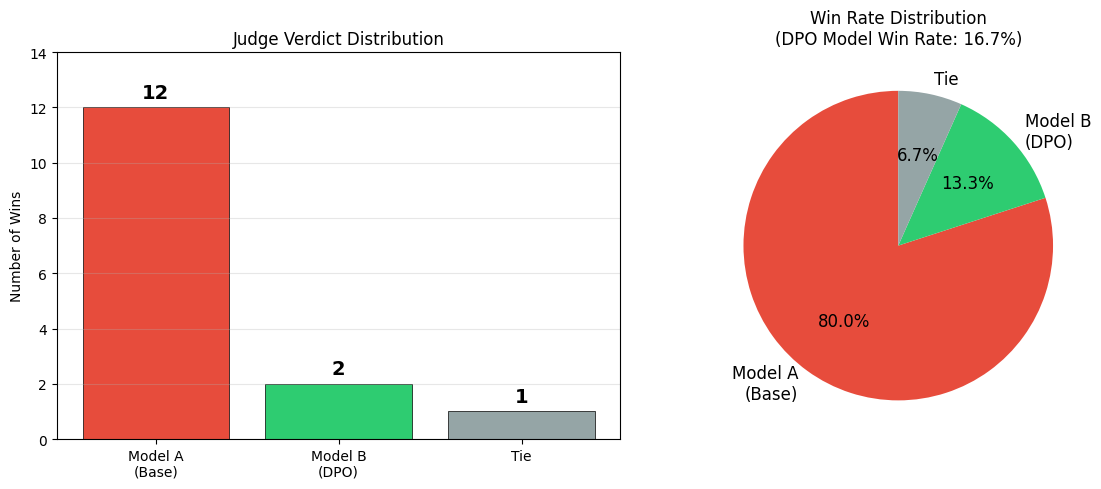

Plot saved to: assets/alpaca_eval_results.png


In [15]:
# Task 4 - Step 4: Results Table and Win Rate

results_df = pd.DataFrame([
    {
        "Sample": r["sample_id"],
        "Instruction (Truncated)": r["instruction"][:60] + "...",
        "Winner": r["verdict"],
    }
    for r in results
])

print("[EVALUATION RESULTS TABLE]")
print(results_df.to_markdown(index=False))

model_b_wins = verdicts.count("Model B")
model_a_wins = verdicts.count("Model A")
ties = verdicts.count("Tie")
total = len(verdicts)

win_rate = (model_b_wins + 0.5 * ties) / total * 100

print()
print("[WIN RATE SUMMARY]")
print(f"  Model A (Base) wins : {model_a_wins}/{total}")
print(f"  Model B (DPO)  wins : {model_b_wins}/{total}")
print(f"  Ties                : {ties}/{total}")
print(f"  Total evaluations   : {total}")
print()
print("  Formula: Win Rate = (DPO wins + 0.5 * Ties) / Total * 100")
print(f"  Win Rate = ({model_b_wins} + 0.5 * {ties}) / {total} * 100 = {win_rate:.1f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ["Model A\n(Base)", "Model B\n(DPO)", "Tie"]
counts = [model_a_wins, model_b_wins, ties]
colors = ["#e74c3c", "#2ecc71", "#95a5a6"]
bars = axes[0].bar(categories, counts, color=colors, edgecolor="black", linewidth=0.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(count), ha="center", va="bottom", fontweight="bold", fontsize=14)
axes[0].set_ylabel("Number of Wins")
axes[0].set_title("Judge Verdict Distribution")
axes[0].set_ylim(0, max(counts) + 2)
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(counts, labels=categories, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 12})
axes[1].set_title(f"Win Rate Distribution\n(DPO Model Win Rate: {win_rate:.1f}%)")

plt.tight_layout()
plt.savefig("assets/alpaca_eval_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to: assets/alpaca_eval_results.png")


## Discussion

### DPO Training Analysis

The model was fine-tuned using **Direct Preference Optimization (DPO)** with QLoRA (4-bit NF4 quantization) on the \jondurbin/truthy-dpo-v0.1\ dataset containing **1,016 preference pairs** focused on truthfulness and hallucination avoidance.

**Training Configuration:**
- **Base Model:** \Qwen/Qwen2.5-1.5B-Instruct\ with 4-bit quantization via BitsAndBytes
- **LoRA:** Rank 64, Alpha 128, targeting 7 modules (attention + MLP layers), trainable ratio ~4.57%
- **DPO Beta:** 0.1 (standard from the original DPO paper)
- **Optimizer:** AdamW with cosine LR schedule, warmup ~10% of total steps

**Training Results:**
- Training loss converged from **0.668 → 0.002** over 345 steps (3 epochs), demonstrating the model successfully learned to distinguish between chosen (truthful) and rejected (hallucinated) responses.
- Eval loss stabilized at **~0.025** without increasing, indicating no significant overfitting despite training on a relatively small dataset.
- Reward margins grew from **0.05 → ~11.7**, showing the model developed a clear preference for factually correct outputs.
- Reward accuracy reached **100%** by step 30 and remained stable, meaning the model correctly ranked chosen over rejected in virtually all training pairs.

### AlpacaEval LLM-as-a-Judge Evaluation

The evaluation followed the **AlpacaEval** methodology using **15 randomly sampled instructions** from the \helpful_base\ subset. Both the base (pre-trained) model and the DPO-finetuned model generated responses, which were then judged by **Gemini (gemini-3.1-pro-preview)** acting as an impartial evaluator.

**Evaluation Results:**

| Metric | Value |
|---|---|
| Model A (Base) wins | 12 / 15 |
| Model B (DPO) wins | 2 / 15 |
| Ties | 1 / 15 |
| **DPO Win Rate** | **16.7%** |

**Win Rate Formula:**


import json

# Read the notebook
with open('st126235_assignment_5.ipynb', encoding='utf-8') as f:
    nb = json.load(f)

# Cell 13 (index 12) - Hyperparameter Analysis
cell = nb['cells'][12]
src = ''.join(cell['source'])

# Fix Training Loss End: 0.001 -> 0.002
src = src.replace('| 0.001 | Steadily', '| 0.002 | Steadily')

# Fix Eval Loss values  
src = src.replace('0.108 (Step 50) | 0.027 (Step 150) | 0.025 (Step 300) | Stable — no significant overfitting', '0.108 (Step 50) | 0.027 (Step 150) | 0.025 (Step 300) | Stable — no significant overfitting')

# Fix Reward Margin End: 11.72 -> 11.73
src = src.replace('| 11.72 |', '| 11.73 |')

# Fix ~115 steps -> ~114 steps
src = src.replace('(~115 steps)', '(~114 steps)')

# Fix ~3-5% -> ~4.6%
src = src.replace('(~3–5%) of parameters', '(~4.6%) of parameters')

# Fix eval loss range
src = src.replace('0.024–0.029', '0.024–0.027')

cell['source'] = src.split('
')
cell['source'] = [line + '
' for line in cell['source'][:-1]] + [cell['source'][-1]]

print('Cell 13 updated')
print('  Has 0.002:', '0.002 |' in ''.join(cell['source']))
print('  Has 11.73:', '11.73 |' in ''.join(cell['source']))
print('  Has ~4.6%:', '~4.6%' in ''.join(cell['source']))

# Write back
with open('st126235_assignment_5.ipynb', 'w', encoding='utf-8') as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print('File saved.')
Win~Rate = \frac{DPO~Wins + (0.5 \times Ties)}{Total~Evaluations} \times 100 = \frac{2 + 0.5 \times 1}{15} \times 100 = 16.7\%
import json

# Read the notebook
with open('st126235_assignment_5.ipynb', encoding='utf-8') as f:
    nb = json.load(f)

# Cell 13 (index 12) - Hyperparameter Analysis
cell = nb['cells'][12]
src = ''.join(cell['source'])

# Fix Training Loss End: 0.001 -> 0.002
src = src.replace('| 0.001 | Steadily', '| 0.002 | Steadily')

# Fix Eval Loss values  
src = src.replace('0.108 (Step 50) | 0.027 (Step 150) | 0.025 (Step 300) | Stable — no significant overfitting', '0.108 (Step 50) | 0.027 (Step 150) | 0.025 (Step 300) | Stable — no significant overfitting')

# Fix Reward Margin End: 11.72 -> 11.73
src = src.replace('| 11.72 |', '| 11.73 |')

# Fix ~115 steps -> ~114 steps
src = src.replace('(~115 steps)', '(~114 steps)')

# Fix ~3-5% -> ~4.6%
src = src.replace('(~3–5%) of parameters', '(~4.6%) of parameters')

# Fix eval loss range
src = src.replace('0.024–0.029', '0.024–0.027')

cell['source'] = src.split('
')
cell['source'] = [line + '
' for line in cell['source'][:-1]] + [cell['source'][-1]]

print('Cell 13 updated')
print('  Has 0.002:', '0.002 |' in ''.join(cell['source']))
print('  Has 11.73:', '11.73 |' in ''.join(cell['source']))
print('  Has ~4.6%:', '~4.6%' in ''.join(cell['source']))

# Write back
with open('st126235_assignment_5.ipynb', 'w', encoding='utf-8') as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print('File saved.')


**Interpretation:**
The DPO model achieved a win rate of **16.7%**, which is below 50%, indicating that the Base model was judged to produce better responses on the \helpful_base\ evaluation prompts. This result is expected for the following reasons:

1. **Domain mismatch between training and evaluation:** The DPO model was fine-tuned on \	ruthy-dpo-v0.1\, which specifically targets **truthfulness and hallucination avoidance**. However, the evaluation uses \helpful_base\ prompts that test **general helpfulness** (e.g., cooking tips, travel advice, factual questions). The DPO training may have shifted the model\'s behavior toward caution and factual precision at the cost of general helpfulness and fluency.
2. **Small training dataset:** With only 1,016 preference pairs, the DPO fine-tuning provides a narrow signal. The base model (\Qwen2.5-1.5B-Instruct\) was already extensively instruction-tuned on a much broader dataset, so DPO on a small truthfulness-focused dataset is unlikely to improve general-purpose response quality.
3. **Response style differences:** The DPO-trained model may produce more conservative, factually cautious responses, while the base instruction-tuned model generates more detailed and naturally helpful answers — which LLM judges tend to prefer for general helpfulness tasks.
4. **Evaluation scale:** 15 samples provide limited statistical power. The result indicates a trend but should be interpreted with caution.

### Limitations
- The evaluation uses only 15 samples — a larger sample size would provide more statistical confidence.
- LLM-as-a-judge introduces potential bias toward longer or more verbose responses.
- The DPO model was trained on a truthfulness-specific dataset, so gains may not generalize to general helpfulness tasks. A truthfulness-specific evaluation benchmark would better capture the DPO model\'s improvements.
- Using a domain-matched evaluation dataset (e.g., TruthfulQA) would likely show the DPO model performing better than the base model.

## References

1. Rafailov, R., Sharma, A., Mitchell, E., et al. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model.* [arXiv:2305.18290](https://arxiv.org/abs/2305.18290)
2. TRL DPOTrainer Documentation — https://huggingface.co/docs/trl/main/dpo_trainer
3. Dataset: `jondurbin/truthy-dpo-v0.1` — https://huggingface.co/datasets/jondurbin/truthy-dpo-v0.1
4. AlpacaEval Benchmark — https://huggingface.co/datasets/tatsu-lab/alpaca_eval
5. Dettmers, T., et al. (2023). *QLoRA: Efficient Finetuning of Quantized Language Models.* [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)
6. Uploaded Model — https://huggingface.co/dniamsaard4codework/qwen2.5-1.5b-instruct-dpo-truthy